# Practica Evaluativa
Resolucion de los ejercicios 1 al 6 con la misma logica de clase (OpenCV, NumPy y Matplotlib).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

salida = Path('salidas_practica5_pdf')
salida.mkdir(exist_ok=True)

def cargar_imagen(base):
    candidatos = [f'{base}.jpg', f'{base}.jpeg', f'{base}.jpg.jpeg', f'{base}.png', base]
    for nombre in candidatos:
        img = cv2.imread(nombre, cv2.IMREAD_COLOR)
        if img is not None:
            return img, nombre
    raise FileNotFoundError(f'No se encontro la imagen para base: {base}')

## Ejercicio 1
Recorte del punto de interes en imagenP.

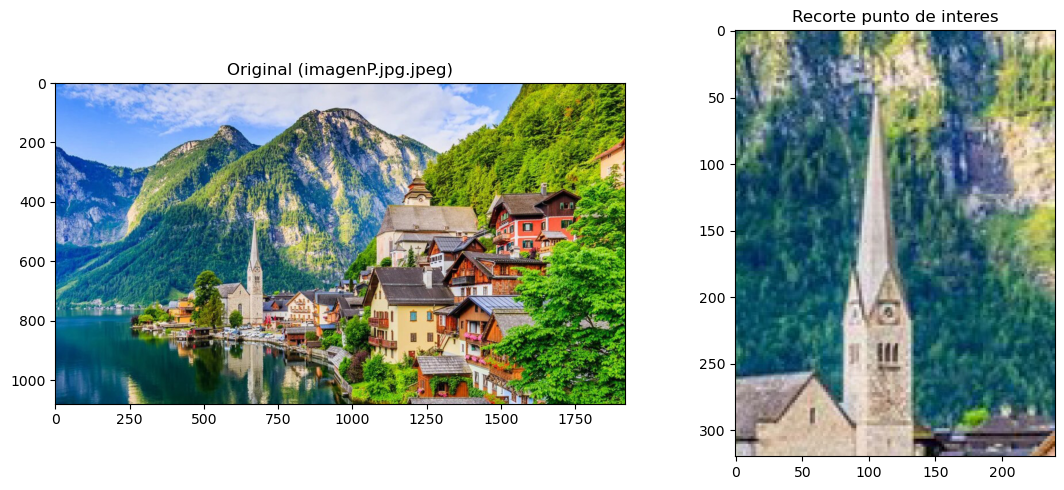

In [2]:
img_p_bgr, ruta_p = cargar_imagen('imagenP')
img_p_rgb = cv2.cvtColor(img_p_bgr, cv2.COLOR_BGR2RGB)

x, y, w, h = 565, 415, 240, 320
recorte = img_p_rgb[y:y+h, x:x+w]

cv2.imwrite(str(salida / 'ej1_recorte.png'), cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title(f'Original ({ruta_p})')
plt.imshow(img_p_rgb)
plt.axis('on')
plt.subplot(1, 2, 2)
plt.title('Recorte punto de interes')
plt.imshow(recorte)
plt.axis('on')
plt.tight_layout()
plt.show()

## Ejercicio 2
Degradado lineal a color con la misma gama mostrada en el ejemplo.

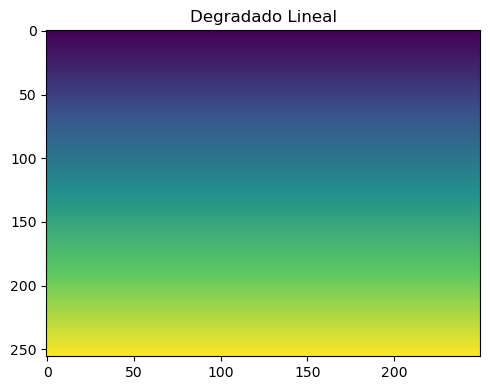

In [3]:
from matplotlib.colors import LinearSegmentedColormap

h, w = 256, 250
base = np.tile(np.linspace(0, 1, h, dtype=np.float32)[:, None], (1, w))

colores = [
    (68/255, 1/255, 84/255),
    (59/255, 82/255, 139/255),
    (33/255, 145/255, 140/255),
    (94/255, 201/255, 98/255),
    (253/255, 231/255, 37/255)
]
cmap_lineal = LinearSegmentedColormap.from_list('degradado_clase', colores, N=256)

plt.figure(figsize=(5, 4))
plt.title('Degradado Lineal')
plt.imshow(base, cmap=cmap_lineal, aspect='auto')
plt.axis('on')
plt.tight_layout()
plt.show()

plt.imsave(salida / 'ej2_degradado_lineal.png', base, cmap=cmap_lineal)

## Ejercicio 3
Tablero de ajedrez con casillas de 100x100 px.

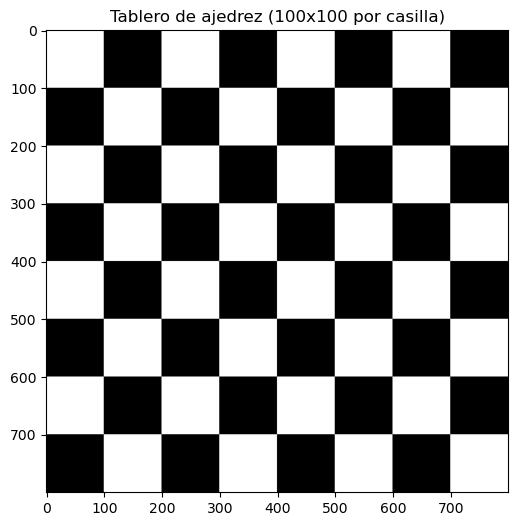

In [4]:
tam_casilla = 100
n = 8
tablero = np.zeros((n * tam_casilla, n * tam_casilla), dtype=np.uint8)

for i in range(n):
    for j in range(n):
        if (i + j) % 2 == 0:
            tablero[i*tam_casilla:(i+1)*tam_casilla, j*tam_casilla:(j+1)*tam_casilla] = 255

cv2.imwrite(str(salida / 'ej3_tablero_100px.png'), tablero)

plt.figure(figsize=(6, 6))
plt.title('Tablero de ajedrez (100x100 por casilla)')
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.axis('on')
plt.show()

## Ejercicio 4
Aplicar posterizacion, solarizacion y todas las paletas de falso color al degradado del ejercicio 2; guardar todos los resultados.

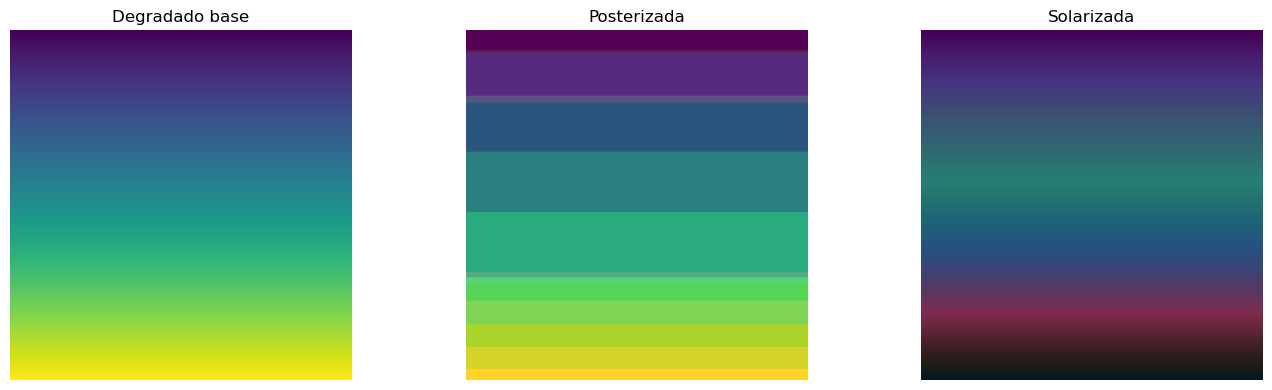

Paletas guardadas: 22 en salidas_practica5_pdf\ej4_falso_color


In [5]:
def posterizar_rgb(imagen_rgb, niveles):
    factor = 255 / niveles
    return (np.round(imagen_rgb / factor) * factor).clip(0, 255).astype(np.uint8)

def solarizar_rgb(imagen_rgb, umbral):
    return np.where(imagen_rgb < umbral, imagen_rgb, 255 - imagen_rgb).astype(np.uint8)

degradado_rgb = (plt.cm.viridis(base)[:, :, :3] * 255).astype(np.uint8)
degradado_gray = cv2.cvtColor(degradado_rgb, cv2.COLOR_RGB2GRAY)

img_poster = posterizar_rgb(degradado_rgb, niveles=6)
img_solar = solarizar_rgb(degradado_rgb, umbral=127)

cv2.imwrite(str(salida / 'ej4_posterizada.png'), cv2.cvtColor(img_poster, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(salida / 'ej4_solarizada.png'), cv2.cvtColor(img_solar, cv2.COLOR_RGB2BGR))

mapas = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
    'DEEPGREEN': cv2.COLORMAP_DEEPGREEN
}

falso_dir = salida / 'ej4_falso_color'
falso_dir.mkdir(exist_ok=True)

for nombre, codigo in mapas.items():
    falso_bgr = cv2.applyColorMap(degradado_gray, codigo)
    cv2.imwrite(str(falso_dir / f'{nombre}.png'), falso_bgr)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.title('Degradado base')
plt.imshow(degradado_rgb)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Posterizada')
plt.imshow(img_poster)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Solarizada')
plt.imshow(img_solar)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Paletas guardadas: {len(mapas)} en {falso_dir}')

## Ejercicio 5
Aplicar un degradado lineal sobre imagen1.

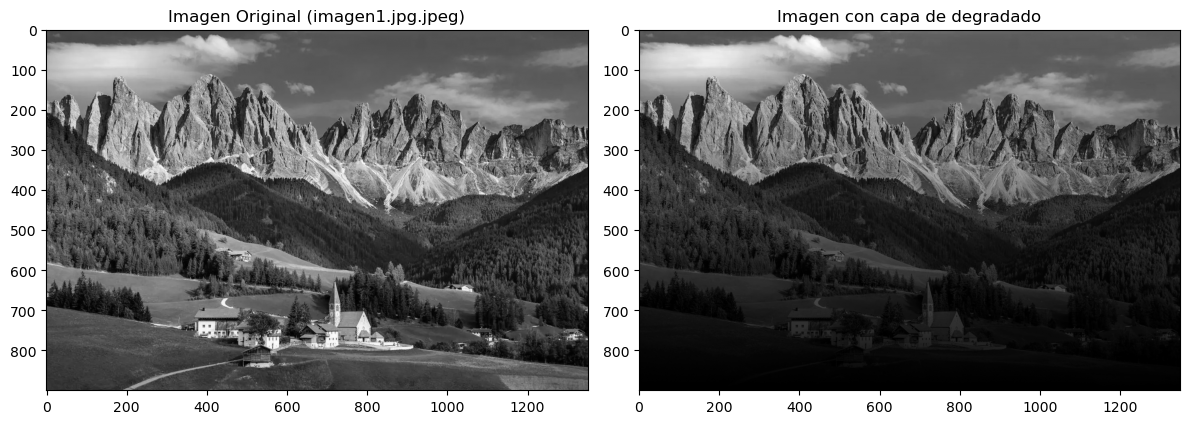

In [6]:
from matplotlib.colors import LinearSegmentedColormap

img1_bgr, ruta_1 = cargar_imagen('imagen1')
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)

h, w = 256, 250
base = np.tile(np.linspace(1, 0, h, dtype=np.float32)[:, None], (1, w))

colores = [
    (255/255, 255/255, 255/255),
    (59/255, 82/255, 139/255),
    (33/255, 145/255, 140/255),
    (94/255, 201/255, 98/255),
    (1/255, 1/255, 1/255)
]
cmap_lineal = LinearSegmentedColormap.from_list('degradado_clase', colores, N=256)

capa_degradado = cv2.resize(base, (img1_gray.shape[1], img1_gray.shape[0]), interpolation=cv2.INTER_LINEAR)
img1_grad = (img1_gray.astype(np.float32) * capa_degradado).clip(0, 255).astype(np.uint8)

plt.imsave(salida / 'ej5_capa_degradado.png', capa_degradado, cmap=cmap_lineal)
cv2.imwrite(str(salida / 'ej5_imagen1_original_gris.png'), img1_gray)
cv2.imwrite(str(salida / 'ej5_imagen1_con_degradado.png'), img1_grad)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title(f'Imagen Original ({ruta_1})')
plt.imshow(img1_gray, cmap='gray')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.title('Imagen con capa de degradado')
plt.imshow(img1_grad, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()

## Ejercicio 6
Imagen original estilo pixel-art usando solo cuadrados, aplicada a Bayer mostrando y guardando todos los resultados con titulo.

Procesando Bayer...


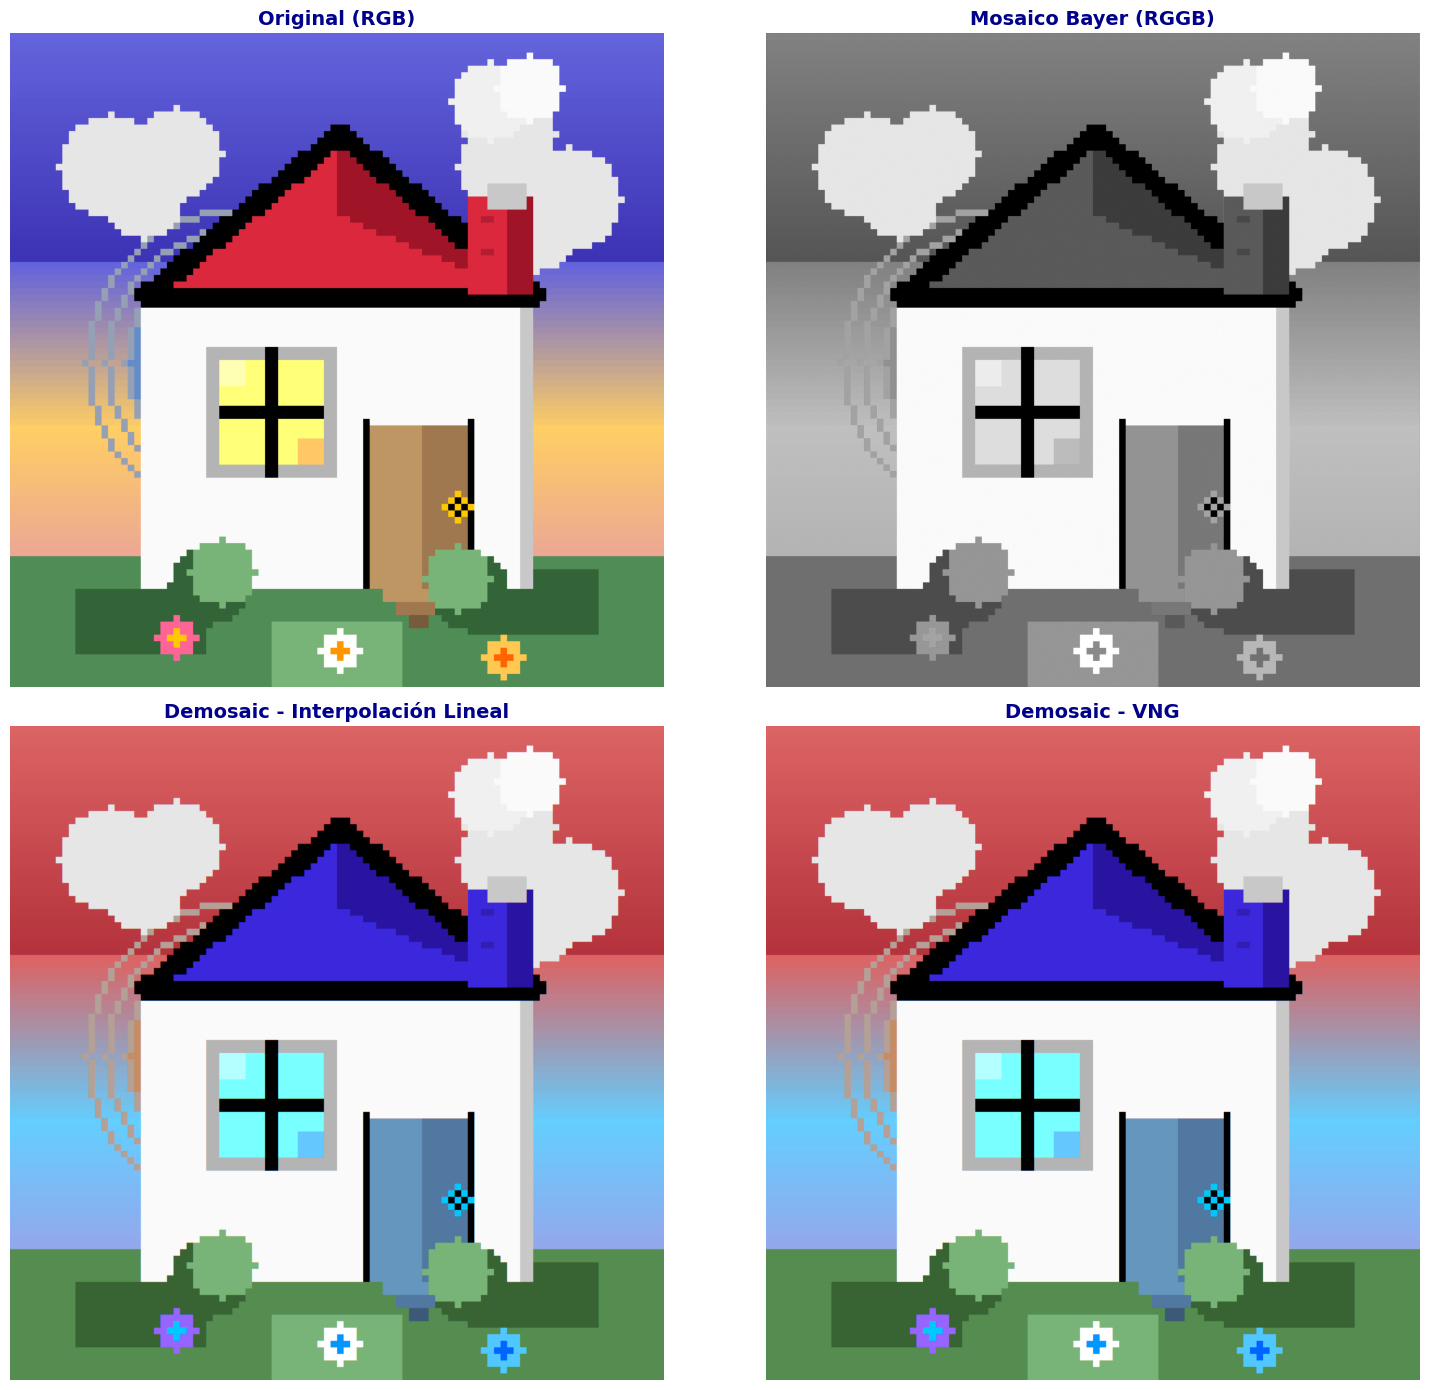


✨ ¡HECHO! Guardado en: D:\PDI26\pdi26\salidas_practica5_pdf
🏡 Imagen: 100x100 píxeles x20 = 2000x2000
🖼️  Generadas 8 imágenes PNG


In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

if 'salida' not in globals():
    salida = Path('salidas_practica5_pdf')
    salida.mkdir(exist_ok=True)

# ===== LIENZO GRANDE =====
lado = 20
filas, cols = 100, 100
lienzo = np.zeros((filas, cols, 3), dtype=np.uint8)

# ===== FONDO ATARDECER HERMOSO =====
for r in range(filas):
    t = r / filas
    if t < 0.35:
        # Azul oscuro arriba
        color = (np.int32(60 + 40 * (1-t/0.35)), 
                 np.int32(50 + 50 * (1-t/0.35)), 
                 np.int32(180 + 40 * (1-t/0.35)))
    elif t < 0.6:
        # Púrpura a naranja
        t_mid = (t - 0.35) / 0.25
        color = (np.int32(100 + 155 * t_mid), 
                 np.int32(100 + 106 * t_mid), 
                 np.int32(220 - 120 * t_mid))
    else:
        # Naranja a rojo cálido
        t_bot = (t - 0.6) / 0.4
        color = (np.int32(255 - 40 * t_bot), 
                 np.int32(206 - 80 * t_bot), 
                 np.int32(100 + 100 * t_bot))
    lienzo[r, :] = color

# ===== PALETA BONITA =====
NEGRO = (0, 0, 0)
BLANCO = (250, 250, 250)
BLANCO_LUZ = (255, 255, 180)
ROJO_TECHO = (220, 40, 60)
ROJO_SOMBRA = (160, 20, 40)
VERDE_PASTO = (80, 140, 85)
VERDE_CLARO = (120, 180, 120)
VERDE_OSCURO = (50, 100, 55)
AMARILLO_VENTANA = (255, 255, 120)
NARANJA_VENTANA = (255, 200, 100)
MARRON_PUERTA = (160, 120, 80)
MARRON_CLARO = (190, 150, 100)
GRIS_HUMO = (230, 230, 230)
GRIS_MARCO = (180, 180, 180)

def pintar_rect(img, r0, r1, c0, c1, color):
    if r0 >= 0 and r1 <= img.shape[0] and c0 >= 0 and c1 <= img.shape[1]:
        img[r0:r1, c0:c1] = color

# ===== CESPED CON VARIACIÓN =====
pintar_rect(lienzo, 80, 100, 0, 100, VERDE_PASTO)
# Manchas de pasto más oscuro
pintar_rect(lienzo, 85, 95, 10, 30, VERDE_OSCURO)
pintar_rect(lienzo, 82, 92, 70, 90, VERDE_OSCURO)
# Pasto más claro
pintar_rect(lienzo, 90, 100, 40, 60, VERDE_CLARO)

# ===== SOL HERMOSO =====
cv2.circle(lienzo, (35, 50), 18, (100, 140, 200), -1)  # Halo azul
cv2.circle(lienzo, (35, 50), 15, (180, 180, 100), -1)  # Naranja
cv2.circle(lienzo, (35, 50), 12, (255, 230, 100), -1)  # Centro amarillo

# Efecto de reflejo
for i in range(3):
    cv2.circle(lienzo, (35, 50), 18 + i*3, (150, 160, 180), 1)

# ===== NUBES BONITAS =====
# Nube 1 (izquierda)
cv2.circle(lienzo, (15, 20), 8, GRIS_HUMO, -1)
cv2.circle(lienzo, (25, 18), 7, GRIS_HUMO, -1)
cv2.circle(lienzo, (20, 25), 6, GRIS_HUMO, -1)

# Nube 2 (derecha)
cv2.circle(lienzo, (85, 25), 8, GRIS_HUMO, -1)
cv2.circle(lienzo, (75, 20), 7, GRIS_HUMO, -1)
cv2.circle(lienzo, (80, 30), 6, GRIS_HUMO, -1)

# ===== CASA - PARED PRINCIPAL MÁS GRANDE =====
pintar_rect(lienzo, 40, 85, 20, 80, BLANCO)
# Sombra lateral
pintar_rect(lienzo, 40, 85, 78, 80, (200, 200, 200))

# ===== TECHO TRIANGULAR BONITO =====
pts_techo = np.array([[20, 40], [50, 15], [80, 40]], dtype=np.int32)
cv2.fillPoly(lienzo, [pts_techo], ROJO_TECHO)
# Sombra en el techo
pts_sombra = np.array([[50, 15], [80, 40], [50, 27]], dtype=np.int32)
cv2.fillPoly(lienzo, [pts_sombra], ROJO_SOMBRA)
# Borde negro
cv2.polylines(lienzo, [pts_techo], True, NEGRO, 2)

# ===== VENTANA FRONTAL GRANDE (4 CRISTALES) =====
pintar_rect(lienzo, 48, 68, 30, 50, GRIS_MARCO)  # Marco gris
pintar_rect(lienzo, 50, 66, 32, 48, AMARILLO_VENTANA)  # Cristal

# Divisiones
pintar_rect(lienzo, 48, 68, 39, 41, NEGRO)  # Línea vertical
pintar_rect(lienzo, 57, 59, 32, 48, NEGRO)  # Línea horizontal

# Reflejos
pintar_rect(lienzo, 50, 54, 32, 36, BLANCO_LUZ)
pintar_rect(lienzo, 62, 66, 44, 48, NARANJA_VENTANA)

# ===== PUERTA BONITA =====
pintar_rect(lienzo, 60, 85, 55, 70, MARRON_CLARO)
# Panel derecho más oscuro
pintar_rect(lienzo, 60, 85, 63, 70, MARRON_PUERTA)
# Marco
pintar_rect(lienzo, 59, 85, 54, 55, NEGRO)
pintar_rect(lienzo, 59, 85, 70, 71, NEGRO)
# Línea de luz en la puerta
pintar_rect(lienzo, 60, 85, 62, 63, MARRON_CLARO)
# Picaporte
cv2.circle(lienzo, (68, 72), 2, (255, 200, 0), -1)
cv2.circle(lienzo, (68, 72), 1, NEGRO, 1)

# ===== ESCALONES =====
pintar_rect(lienzo, 85, 87, 57, 68, MARRON_CLARO)
pintar_rect(lienzo, 87, 89, 59, 66, MARRON_PUERTA)
pintar_rect(lienzo, 89, 91, 61, 64, (120, 90, 60))

# ===== CHIMENEA ROJA =====
pintar_rect(lienzo, 25, 40, 70, 80, ROJO_TECHO)
# Sombra
pintar_rect(lienzo, 25, 40, 76, 80, ROJO_SOMBRA)
# Detalle de ladrillo
for i in range(2):
    pintar_rect(lienzo, 28 + i*5, 29 + i*5, 72, 74, (180, 30, 50))
# Boca de la chimenea
pintar_rect(lienzo, 23, 27, 73, 79, (200, 200, 200))

# ===== HUMO SALIENDO =====
cv2.circle(lienzo, (76, 15), 7, GRIS_HUMO, -1)
cv2.circle(lienzo, (73, 10), 6, (240, 240, 240), -1)
cv2.circle(lienzo, (79, 8), 5, (250, 250, 250), -1)

# ===== FLORES EN EL PASTO =====
# Flor 1 (roja)
cv2.circle(lienzo, (25, 92), 3, (255, 100, 150), -1)
cv2.circle(lienzo, (25, 92), 1, (255, 200, 0), -1)

# Flor 2 (amarilla)
cv2.circle(lienzo, (75, 95), 3, (255, 200, 80), -1)
cv2.circle(lienzo, (75, 95), 1, (255, 100, 0), -1)

# Flor 3 (blanca)
cv2.circle(lienzo, (50, 94), 3, (255, 255, 255), -1)
cv2.circle(lienzo, (50, 94), 1, (255, 150, 0), -1)

# ===== ARBUSTOS DECORATIVOS =====
cv2.circle(lienzo, (30, 84), 6, VERDE_OSCURO, -1)
cv2.circle(lienzo, (32, 82), 5, VERDE_CLARO, -1)

cv2.circle(lienzo, (70, 85), 6, VERDE_OSCURO, -1)
cv2.circle(lienzo, (68, 83), 5, VERDE_CLARO, -1)

# ===== AMPLIAR IMAGEN =====
img_rgb = np.repeat(np.repeat(lienzo, lado, axis=0), lado, axis=1)

# ===== FUNCIONES BAYER =====
def rgb_a_bayer(rgb, patron):
    h, w, _ = rgb.shape
    bayer = np.zeros((h, w), dtype=np.uint8)
    if patron == 'RGGB':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 0]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 1]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 1]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 2]
    elif patron == 'BGGR':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 2]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 1]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 1]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 0]
    elif patron == 'GBRG':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 1]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 2]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 0]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 1]
    elif patron == 'GRBG':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 1]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 0]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 2]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 1]
    return bayer

# ===== GUARDAR =====
cv2.imwrite(str(salida / 'ej6_original.png'), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

demosaic_all = {
    'RGGB': cv2.COLOR_BAYER_RG2RGB,
    'BGGR': cv2.COLOR_BAYER_BG2RGB,
    'GBRG': cv2.COLOR_BAYER_GB2RGB,
    'GRBG': cv2.COLOR_BAYER_GR2RGB
}

print("Procesando Bayer...")
for patron, cod in demosaic_all.items():
    mosaico = rgb_a_bayer(img_rgb, patron)
    reconstruida = cv2.cvtColor(mosaico, cod)
    cv2.imwrite(str(salida / f'ej6_{patron}_mosaico.png'), mosaico)
    cv2.imwrite(str(salida / f'ej6_{patron}_reconstruida.png'), cv2.cvtColor(reconstruida, cv2.COLOR_RGB2BGR))

# ===== VISUALIZACIÓN =====
patron_visual = 'RGGB'
cod_default = cv2.COLOR_BAYER_RG2RGB
cod_vng = cv2.COLOR_BAYER_RG2RGB_VNG

mosaico = rgb_a_bayer(img_rgb, patron_visual)
dem_default = cv2.cvtColor(mosaico, cod_default)
dem_vng = cv2.cvtColor(mosaico, cod_vng)

# ===== FIGURA BONITA =====
fig, axs = plt.subplots(2, 2, figsize=(16, 14))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Original (RGB)', fontsize=14, fontweight='bold', color='darkblue')
axs[0, 0].axis('off')

axs[0, 1].imshow(mosaico, cmap='gray')
axs[0, 1].set_title(f'Mosaico Bayer ({patron_visual})', fontsize=14, fontweight='bold', color='darkblue')
axs[0, 1].axis('off')

axs[1, 0].imshow(dem_default)
axs[1, 0].set_title('Demosaic - Interpolación Lineal', fontsize=14, fontweight='bold', color='darkblue')
axs[1, 0].axis('off')

axs[1, 1].imshow(dem_vng)
axs[1, 1].set_title('Demosaic - VNG', fontsize=14, fontweight='bold', color='darkblue')
axs[1, 1].axis('off')

plt.tight_layout()
plt.savefig(str(salida / 'ej6_RESULTADO_FINAL.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✨ ¡HECHO! Guardado en: {salida.resolve()}')
print(f'🏡 Imagen: 100x100 píxeles x{lado} = {100*lado}x{100*lado}')
print(f'🖼️  Generadas 8 imágenes PNG')